# Pretrend Analysis

- GTP 7-20-2026
- Goal: test parallel trends on pre-period Panel A data before DiD / event study; document verdict (parallel, or adjustment needed + deviations log entry)
- Data: `data/processed/panel_station_week.parquet` (primary sample only)
- Criterion (analysis plan S1): joint test on pre-treatment monthly leads, **pass if p > 0.10**


## Verdict

**Adjustment needed.** Parallel trends are rejected for both `crz` vs `control` and `border` vs `control` on the registered pre-period (2022-01-03 to 2024-06-02).

| Contrast | Joint Wald (monthly leads) | p | Pass (p > 0.10)? |
|---|---:|---:|:---:|
| CRZ vs control | χ²(28) = 668.1 | ≈ 0 | No |
| Border vs control | χ²(28) = 348.5 | ≈ 0 | No |

**Pattern:** CRZ stations grow faster than controls through the pre-period (differential log slope ≈ 0.002 per week, p ≈ 0). The gap is a 2022 post-Omicron catch-up (early leads ≈ -0.15 to -0.37 log points vs late-pre reference). From 2023-07 the *linear* differential slope is insignificant (p = 0.40), but the strict monthly joint test still fails on small month-to-month spikes.

**Adjustment (logged in `config/analysis_plan.md` §12):**
1. S1/S2 primary DiD specs include **station-specific linear trends**; unadjusted TWFE kept as robustness only.
2. DiD estimation pre-window starts **2023-07-01** (`did_pre_start` in `treatment.yaml`); registered `pre_start` kept for SC / SDID.
3. Interpretive weight for systemwide RQ1 shifts toward **S3 / S5** (cross-city SC and SDID), which do not require parallel trends in levels.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
import yaml
from scipy import stats

plt.rcParams["figure.figsize"] = (12, 4.5)
pd.set_option("display.max_columns", None)

ROOT = Path("..").resolve()
with open(ROOT / "config" / "treatment.yaml") as f:
    TREATMENT = yaml.safe_load(f)

windows = TREATMENT["sample_windows"]
T0 = pd.Timestamp(TREATMENT["treatment"]["t0"])
PAUSE = pd.Timestamp("2024-06-05")
PRE_START = pd.Timestamp(windows["pre_start"])
PRE_END = pd.Timestamp(windows["pre_end"])
DID_PRE_START = pd.Timestamp(windows.get("did_pre_start", "2023-07-01"))
ALPHA = 0.10

ZONE_COLORS = {"crz": "#c0392b", "border": "#e67e22", "control": "#2980b9"}

panel = pd.read_parquet(ROOT / "data/processed/panel_station_week.parquet")
main = panel[
    panel["primary_sample"] & panel["zone"].isin(["crz", "border", "control"])
].copy()
main["week_start"] = pd.to_datetime(main["week_start"])
pre = main[main["period"] == "pre"].copy()

print(pre.groupby("zone")["station_complex_id"].nunique())
print("pre weeks", pre["week_start"].nunique(), "rows", len(pre))
print("registered pre:", PRE_START.date(), "→", PRE_END.date())
print("did_pre_start:", DID_PRE_START.date())


zone
border      14
control    324
crz         66
Name: station_complex_id, dtype: int64
pre weeks 126 rows 50904
registered pre: 2022-01-03 → 2024-06-02
did_pre_start: 2023-07-01


## 1. Visual parallel trends (pre-period only)


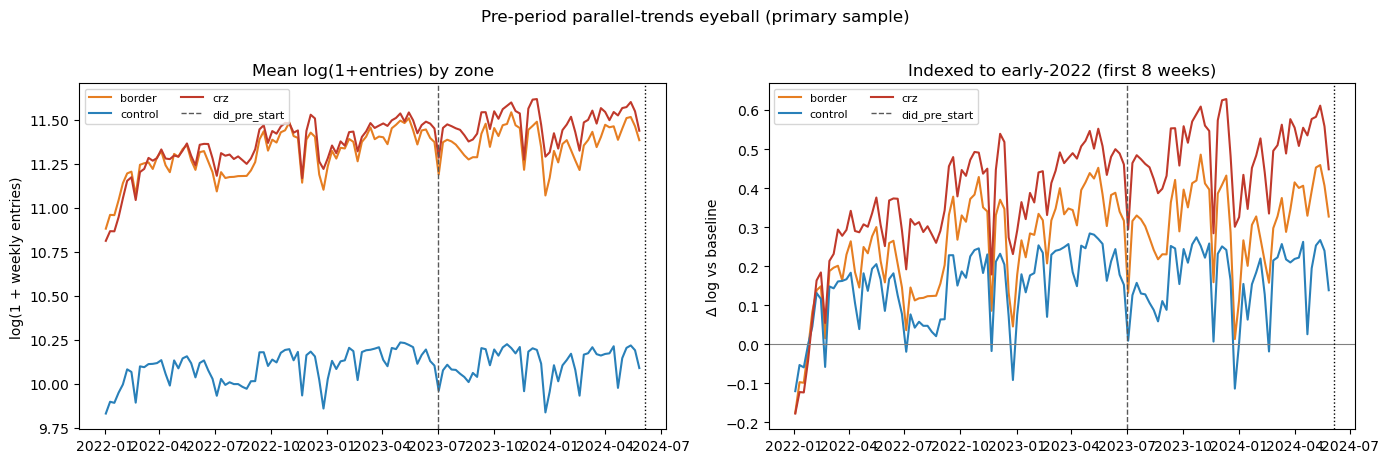

In [2]:
weekly = (
    pre.groupby(["week_start", "zone"], as_index=False)["log_weekly_entries"]
    .mean()
    .sort_values("week_start")
)
base = (
    pre[pre["week_start"] < PRE_START + pd.Timedelta(weeks=8)]
    .groupby("zone")["log_weekly_entries"]
    .mean()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for z, g in weekly.groupby("zone"):
    axes[0].plot(g["week_start"], g["log_weekly_entries"], color=ZONE_COLORS[z], label=z, lw=1.5)
    axes[1].plot(
        g["week_start"],
        g["log_weekly_entries"] - base[z],
        color=ZONE_COLORS[z],
        label=z,
        lw=1.5,
    )
axes[0].set_title("Mean log(1+entries) by zone")
axes[0].set_ylabel("log(1 + weekly entries)")
axes[1].axhline(0, color="0.5", lw=0.8)
axes[1].set_title("Indexed to early-2022 (first 8 weeks)")
axes[1].set_ylabel("Δ log vs baseline")
for ax in axes:
    ax.axvline(PAUSE, color="black", lw=1, ls=":")
    ax.axvline(DID_PRE_START, color="0.35", lw=1, ls="--", label="did_pre_start")
    ax.legend(loc="upper left", ncol=2, fontsize=8)
fig.suptitle("Pre-period parallel-trends eyeball (primary sample)", y=1.02)
fig.tight_layout()
fig.savefig(ROOT / "results/figures/pretrends_zone_means.png", dpi=150, bbox_inches="tight")
plt.show()


## 2. Differential linear trends (station FE, cluster SE)

Model on pre-period only: $y_{it} = \alpha_i + \beta t + \gamma (t \times \mathrm{Treated}_i) + e_{it}$.  
Parallel linear trends ⇒ $\gamma = 0$.


In [3]:
def station_demean(df, col):
    return df[col] - df.groupby("station_complex_id")[col].transform("mean")


def differential_trend(df, treated_zone, outcome="log_weekly_entries"):
    d = df[df["zone"].isin([treated_zone, "control"])].copy()
    d["treated"] = (d["zone"] == treated_zone).astype(float)
    start = d["week_start"].min()
    d["t"] = (d["week_start"] - start).dt.days / 7.0
    d["y"] = d[outcome]
    d["y_dm"] = station_demean(d, "y")
    d["t_dm"] = station_demean(d, "t")
    d["txtr"] = d["t"] * d["treated"]
    d["txtr_dm"] = station_demean(d, "txtr")
    return sm.OLS(d["y_dm"], d[["t_dm", "txtr_dm"]]).fit(
        cov_type="cluster", cov_kwds={"groups": d["station_complex_id"]}
    )


cuts = [
    ("full registered pre", PRE_START),
    ("from 2022-07", pd.Timestamp("2022-07-01")),
    ("from 2023-01", pd.Timestamp("2023-01-01")),
    ("from 2023-07 (did_pre_start)", DID_PRE_START),
    ("from 2024-01", pd.Timestamp("2024-01-01")),
]

rows = []
for label, start in cuts:
    sub = pre[pre["week_start"] >= start]
    for z in ["crz", "border"]:
        m = differential_trend(sub, z)
        rows.append(
            {
                "window": label,
                "contrast": f"{z}_vs_control",
                "diff_slope": float(m.params["txtr_dm"]),
                "se": float(m.bse["txtr_dm"]),
                "pvalue": float(m.pvalues["txtr_dm"]),
                "n_obs": int(m.nobs),
            }
        )

trend_tbl = pd.DataFrame(rows)
display(trend_tbl.round(6))
trend_tbl.to_csv(ROOT / "results/estimates/pretrends_differential_slopes.csv", index=False)


,window,contrast,diff_slope,se,pvalue,n_obs
0,full registered pre,crz_vs_control,0.002085,0.000212,0.000000,49140
1,full registered pre,border_vs_control,0.001058,0.000516,0.040468,42588
2,from 2022-07,crz_vs_control,0.001280,0.000274,0.000003,39000
3,from 2022-07,border_vs_control,0.000664,0.000671,0.322615,33800
4,from 2023-01,crz_vs_control,0.001790,0.000341,0.000000,28860
5,from 2023-01,border_vs_control,0.000636,0.000840,0.448562,25012
6,from 2023-07 (did_pre_start),crz_vs_control,0.000276,0.000327,0.399838,18720
7,from 2023-07 (did_pre_start),border_vs_control,0.000152,0.000781,0.845288,16224
8,from 2024-01,crz_vs_control,0.002898,0.001627,0.074926,8580
9,from 2024-01,border_vs_control,0.005083,0.003174,0.109299,7436


## 3. Event-study leads + joint Wald test (plan S1 diagnostic)

TWFE on pre-period: station + week FE, treated × relative-month dummies.  
Reference = last pre month (rel_month = -8, June 2024). Plan S1 uses month before T0 (rel = -1, in washout); the pre-only diagnostic re-references to the last pre month so washout/post never enter.


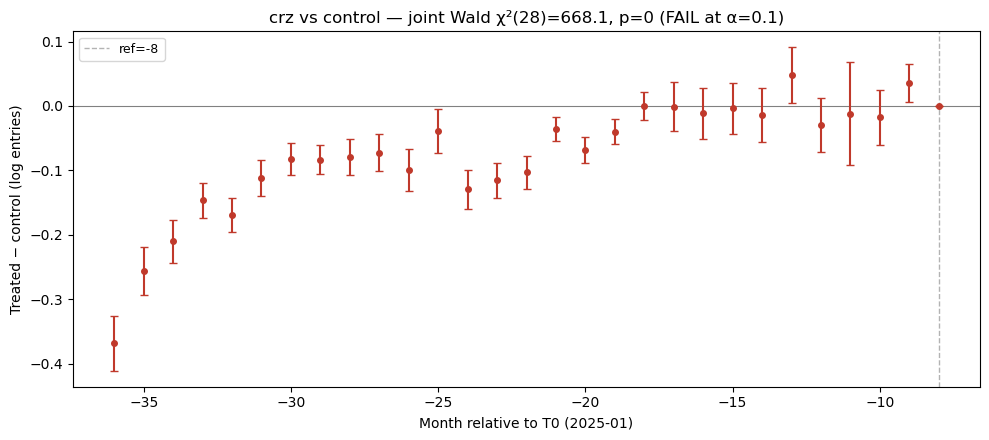

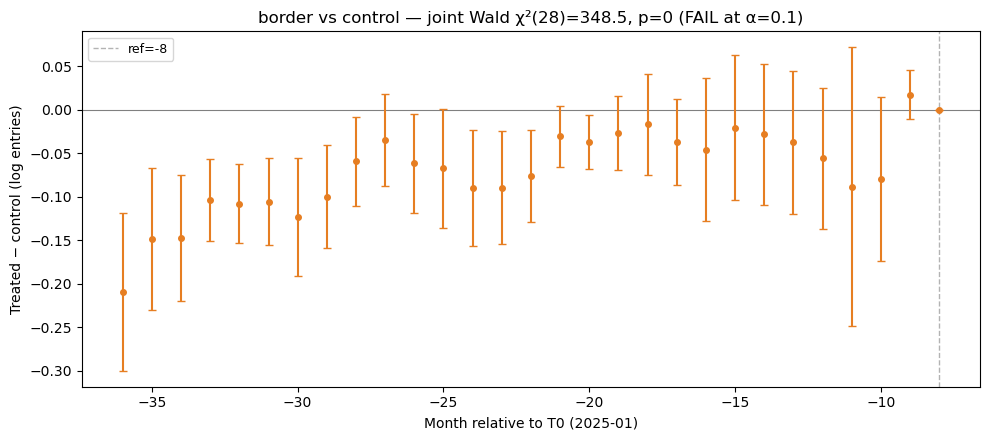

,contrast,ref_rel_month,wald,df,p_joint,pass_alpha_0_10,n_obs
0,crz_vs_control,-8,668.073731,28,0.0,False,49140
1,border_vs_control,-8,348.548786,28,0.0,False,42588


In [4]:
def add_rel_month(df):
    out = df.copy()
    out["year_month"] = out["week_start"].dt.to_period("M")
    t0_month = pd.Timestamp(T0).to_period("M")
    out["rel_month"] = (out["year_month"] - t0_month).apply(lambda p: p.n)
    return out


def event_study_leads(df, treated_zone, outcome="log_weekly_entries", ref=None):
    d = df[df["zone"].isin([treated_zone, "control"])].copy()
    d = add_rel_month(d)
    d["treated"] = (d["zone"] == treated_zone).astype(float)
    d["y"] = d[outcome]
    months = sorted(d["rel_month"].unique())
    if ref is None:
        ref = max(m for m in months if m < 0)
    leads = [m for m in months if m != ref]
    for m in leads:
        d[f"D{m}"] = ((d["rel_month"] == m) & (d["treated"] == 1)).astype(float)
    cols = [f"D{m}" for m in leads]
    work = d[["station_complex_id", "week_start", "y", *cols]].copy()
    for c in ["y", *cols]:
        work[c] = work[c] - work.groupby("station_complex_id")[c].transform("mean")
        work[c] = work[c] - work.groupby("week_start")[c].transform("mean")
    keep = [c for c in cols if work[c].abs().sum() > 1e-12]
    model = sm.OLS(work["y"], work[keep]).fit(
        cov_type="cluster", cov_kwds={"groups": work["station_complex_id"]}
    )
    coefs = []
    for c in keep:
        m = int(c[1:])
        coefs.append(
            {
                "rel_month": m,
                "coef": float(model.params[c]),
                "se": float(model.bse[c]),
                "pvalue": float(model.pvalues[c]),
            }
        )
    coefs.append({"rel_month": ref, "coef": 0.0, "se": 0.0, "pvalue": np.nan})
    coef_df = pd.DataFrame(coefs).sort_values("rel_month").reset_index(drop=True)
    coef_df["ci_low"] = coef_df["coef"] - 1.96 * coef_df["se"]
    coef_df["ci_high"] = coef_df["coef"] + 1.96 * coef_df["se"]

    pre_leads = [c for c in keep if int(c[1:]) < 0]
    R = np.zeros((len(pre_leads), len(model.params)))
    name_to_i = {n: i for i, n in enumerate(model.params.index)}
    for i, c in enumerate(pre_leads):
        R[i, name_to_i[c]] = 1.0
    Rb = R @ model.params.values
    wald = float(Rb.T @ np.linalg.solve(R @ model.cov_params().values @ R.T, Rb))
    p_joint = float(1 - stats.chi2.cdf(wald, len(pre_leads)))
    return {
        "coefs": coef_df,
        "ref": ref,
        "wald": wald,
        "df": len(pre_leads),
        "p_joint": p_joint,
        "n_obs": int(model.nobs),
        "treated_zone": treated_zone,
    }


joint_rows = []
for z in ["crz", "border"]:
    res = event_study_leads(pre, z)
    res["coefs"].to_csv(ROOT / f"results/estimates/pretrends_event_coefs_{z}.csv", index=False)

    fig, ax = plt.subplots(figsize=(10, 4.5))
    c = res["coefs"]
    ax.axhline(0, color="0.5", lw=0.8)
    ax.axvline(res["ref"], color="0.7", lw=1, ls="--", label=f"ref={res['ref']}")
    ax.errorbar(
        c["rel_month"],
        c["coef"],
        yerr=1.96 * c["se"],
        fmt="o",
        color=ZONE_COLORS[z],
        capsize=3,
        ms=4,
    )
    passed = res["p_joint"] > ALPHA
    ax.set_title(
        f"{z} vs control — joint Wald χ²({res['df']})={res['wald']:.1f}, "
        f"p={res['p_joint']:.4g} ({'PASS' if passed else 'FAIL'} at α={ALPHA})"
    )
    ax.set_xlabel("Month relative to T0 (2025-01)")
    ax.set_ylabel("Treated − control (log entries)")
    ax.legend(fontsize=9)
    fig.tight_layout()
    fig.savefig(
        ROOT / f"results/figures/pretrends_event_study_{z}_log_weekly_entries.png",
        dpi=150,
        bbox_inches="tight",
    )
    plt.show()

    joint_rows.append(
        {
            "contrast": f"{z}_vs_control",
            "ref_rel_month": res["ref"],
            "wald": res["wald"],
            "df": res["df"],
            "p_joint": res["p_joint"],
            "pass_alpha_0_10": passed,
            "n_obs": res["n_obs"],
        }
    )

joint_tbl = pd.DataFrame(joint_rows)
display(joint_tbl)
joint_tbl.to_csv(ROOT / "results/estimates/pretrends_joint_tests.csv", index=False)


## 4. Placebo DiD within the pre-period

Split pre at midpoint (2023-03-19): fake post × treated under TWFE. A large "effect" confirms differential pre-trends.


In [5]:
mid = PRE_START + (PRE_END - PRE_START) / 2
print("midpoint:", mid.date())

placebo_rows = []
for z in ["crz", "border"]:
    d = pre[pre["zone"].isin([z, "control"])].copy()
    d["treated"] = (d["zone"] == z).astype(float)
    d["fake_post"] = (d["week_start"] >= mid).astype(float)
    d["DID"] = d["treated"] * d["fake_post"]
    work = d[["station_complex_id", "week_start", "log_weekly_entries", "DID"]].copy()
    work = work.rename(columns={"log_weekly_entries": "y"})
    for c in ["y", "DID"]:
        work[c] = work[c] - work.groupby("station_complex_id")[c].transform("mean")
        work[c] = work[c] - work.groupby("week_start")[c].transform("mean")
    m = sm.OLS(work["y"], work[["DID"]]).fit(
        cov_type="cluster", cov_kwds={"groups": d["station_complex_id"]}
    )
    placebo_rows.append(
        {
            "contrast": f"{z}_vs_control",
            "att": float(m.params["DID"]),
            "se": float(m.bse["DID"]),
            "pvalue": float(m.pvalues["DID"]),
        }
    )

placebo_tbl = pd.DataFrame(placebo_rows)
display(placebo_tbl.round(5))
placebo_tbl.to_csv(ROOT / "results/estimates/pretrends_placebo_did.csv", index=False)


midpoint: 2023-03-19


,contrast,att,se,pvalue
0,crz_vs_control,0.12684,0.01443,0.00000
1,border_vs_control,0.06643,0.03488,0.05687


## 5. Interpretation

- **Registered pre window fails** the S1 parallel-trends diagnostic for both CRZ and border contrasts.
- Failure is **not mysterious**: CRZ (and to a lesser extent border) ridership recovered faster from the pandemic trough than outer-borough controls - visible as large negative early leads that shrink toward zero by mid-2023.
- **Linear** differential trends are compatible with zero from `did_pre_start` = 2023-07-01 (CRZ p = 0.40; border p = 0.85), so a shortened DiD window plus unit trends is a reasonable patch for S1/S2 - not a claim that strict monthly leads all pass.
- Weather / holiday covariates (Central Park series, common across stations) do not absorb the differential.
- Within-NYC DiD remains biased toward zero for systemwide effects under H3/SUTVA anyway; cross-city SC / SDID were already the right tools for aggregate RQ1 and are more important given this diagnostic.

Re-run helper (same outputs): `python notebooks/_pretrends_run.py` from repo root with the `eda` conda env.
